# Core par bloc depuis 2019

Ce notebook charge tous les indices Core depuis la source Excel, trace 3 graphes (Equity, Rates, Credit) depuis le 01/01/2019, puis affiche 3 tableaux avec la volatilité annualisée de chaque indice.

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.core_pipeline_corrected import CoreConfig, lire_theme

START_DATE = pd.Timestamp('2019-01-01')
OUTPUT_DIR = Path('outputs') / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

project_root = Path.cwd()
if not (project_root / 'src').exists():
    candidates = [project_root.parent, project_root.parent.parent]
    project_root = next((p for p in candidates if (p / 'src').exists()), project_root)

excel_candidates = [
    project_root / 'data' / 'univers_core_etf_eur_daily_wide.xlsx',
    project_root / 'univers_core_etf_eur_daily_wide_VF.xlsx',
]
excel_path = next((p for p in excel_candidates if p.exists()), None)
if excel_path is None:
    raise FileNotFoundError('Fichier Core introuvable dans data/ ou à la racine du projet.')

cfg = CoreConfig(core_excel=excel_path)

BLOCKS = {
    'Equity': {
        'sheet_prices': cfg.sheet_equity_prices,
        'sheet_meta': cfg.sheet_equity_meta,
        'color': '#1f77b4',
    },
    'Rates': {
        'sheet_prices': cfg.sheet_rates_prices,
        'sheet_meta': cfg.sheet_rates_meta,
        'color': '#ff7f0e',
    },
    'Credit': {
        'sheet_prices': cfg.sheet_credit_prices,
        'sheet_meta': cfg.sheet_credit_meta,
        'color': '#2ca02c',
    },
}

def _first_valid_date(series: pd.Series) -> pd.Timestamp:
    clean = series.dropna()
    if clean.empty:
        return pd.NaT
    return pd.Timestamp(clean.index.min())

def _load_block(theme_name: str, sheet_prices: str, sheet_meta: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
    prices, meta = lire_theme(cfg, theme_name, sheet_prices, sheet_meta, verbose=False)
    prices = prices.copy().sort_index()
    prices.index = pd.DatetimeIndex(prices.index).tz_localize(None)

    first_dates = prices.apply(_first_valid_date, axis=0)
    eligible_cols = first_dates[first_dates.notna() & (first_dates <= START_DATE)].index.tolist()

    prices = prices[eligible_cols].copy()
    prices = prices.loc[prices.index >= START_DATE].copy()
    prices = prices.dropna(axis=1, how='all')
    meta = meta.reindex(prices.columns).copy()
    first_dates = first_dates.reindex(prices.columns)
    return prices, meta, first_dates

def _robust_base(series: pd.Series, window: int = 5) -> float:
    clean = series.dropna()
    if clean.empty:
        return np.nan
    baseline = clean.iloc[:window].median()
    if pd.isna(baseline) or baseline <= 0:
        positive = clean[clean > 0]
        if positive.empty:
            return np.nan
        baseline = positive.iloc[:window].median()
    return float(baseline)

def _rebase_to_100(prices: pd.DataFrame) -> pd.DataFrame:
    rebased = prices.copy()
    for col in rebased.columns:
        base = _robust_base(rebased[col])
        if pd.isna(base) or base <= 0:
            rebased[col] = np.nan
            continue
        rebased[col] = rebased[col] / base * 100.0
    return rebased

def _annualized_vol_table(prices: pd.DataFrame, meta: pd.DataFrame, first_dates: pd.Series) -> pd.DataFrame:
    returns = prices.pct_change(fill_method=None)
    vol_ann = returns.std(skipna=True) * np.sqrt(252.0)
    n_obs = returns.notna().sum()

    meta_cols = [c for c in ['nom', 'exposition', 'ter_pct', 'devise', 'provider'] if c in meta.columns]
    table = meta.reindex(vol_ann.index)[meta_cols].copy() if meta_cols else pd.DataFrame(index=vol_ann.index)
    table.insert(0, 'ticker', vol_ann.index)
    table['first_valid_date'] = pd.to_datetime(first_dates.reindex(vol_ann.index)).dt.strftime('%Y-%m-%d').values
    table['n_obs_returns'] = n_obs.values
    table['vol_annualisee'] = vol_ann.values
    table = table.sort_values('vol_annualisee', ascending=False, na_position='last').reset_index(drop=True)
    return table

block_data = {}
for block_name, params in BLOCKS.items():
    prices, meta, first_dates = _load_block(block_name, params['sheet_prices'], params['sheet_meta'])
    if prices.empty:
        raise ValueError(
            f'Aucun indice du bloc {block_name} ne commence au plus tard le {START_DATE.date()}.'
        )

    block_data[block_name] = {
        'prices': prices,
        'rebased': _rebase_to_100(prices),
        'vol_table': _annualized_vol_table(prices, meta, first_dates),
        'first_dates': first_dates,
        'color': params['color'],
    }

print(f'Fichier source utilisé : {excel_path}')
print(f'Fenêtre d analyse : {START_DATE.date()} -> aujourd hui')
print(f'Règle de sélection : première date valide <= {START_DATE.date()}')
for block_name, data in block_data.items():
    n_idx = data['prices'].shape[1]
    d_min = data['prices'].index.min().date()
    d_max = data['prices'].index.max().date()
    print(f'- {block_name}: {n_idx} indices retenus | {d_min} -> {d_max}')

Fichier source utilisé : /workspaces/Core_Satellite_Quant/data/univers_core_etf_eur_daily_wide.xlsx
Fenêtre d analyse : 2019-01-01 -> aujourd hui
Règle de sélection : première date valide <= 2019-01-01
- Equity: 14 indices retenus | 2019-01-01 -> 2026-03-02
- Rates: 9 indices retenus | 2019-01-01 -> 2026-03-02
- Credit: 10 indices retenus | 2019-01-01 -> 2026-03-02


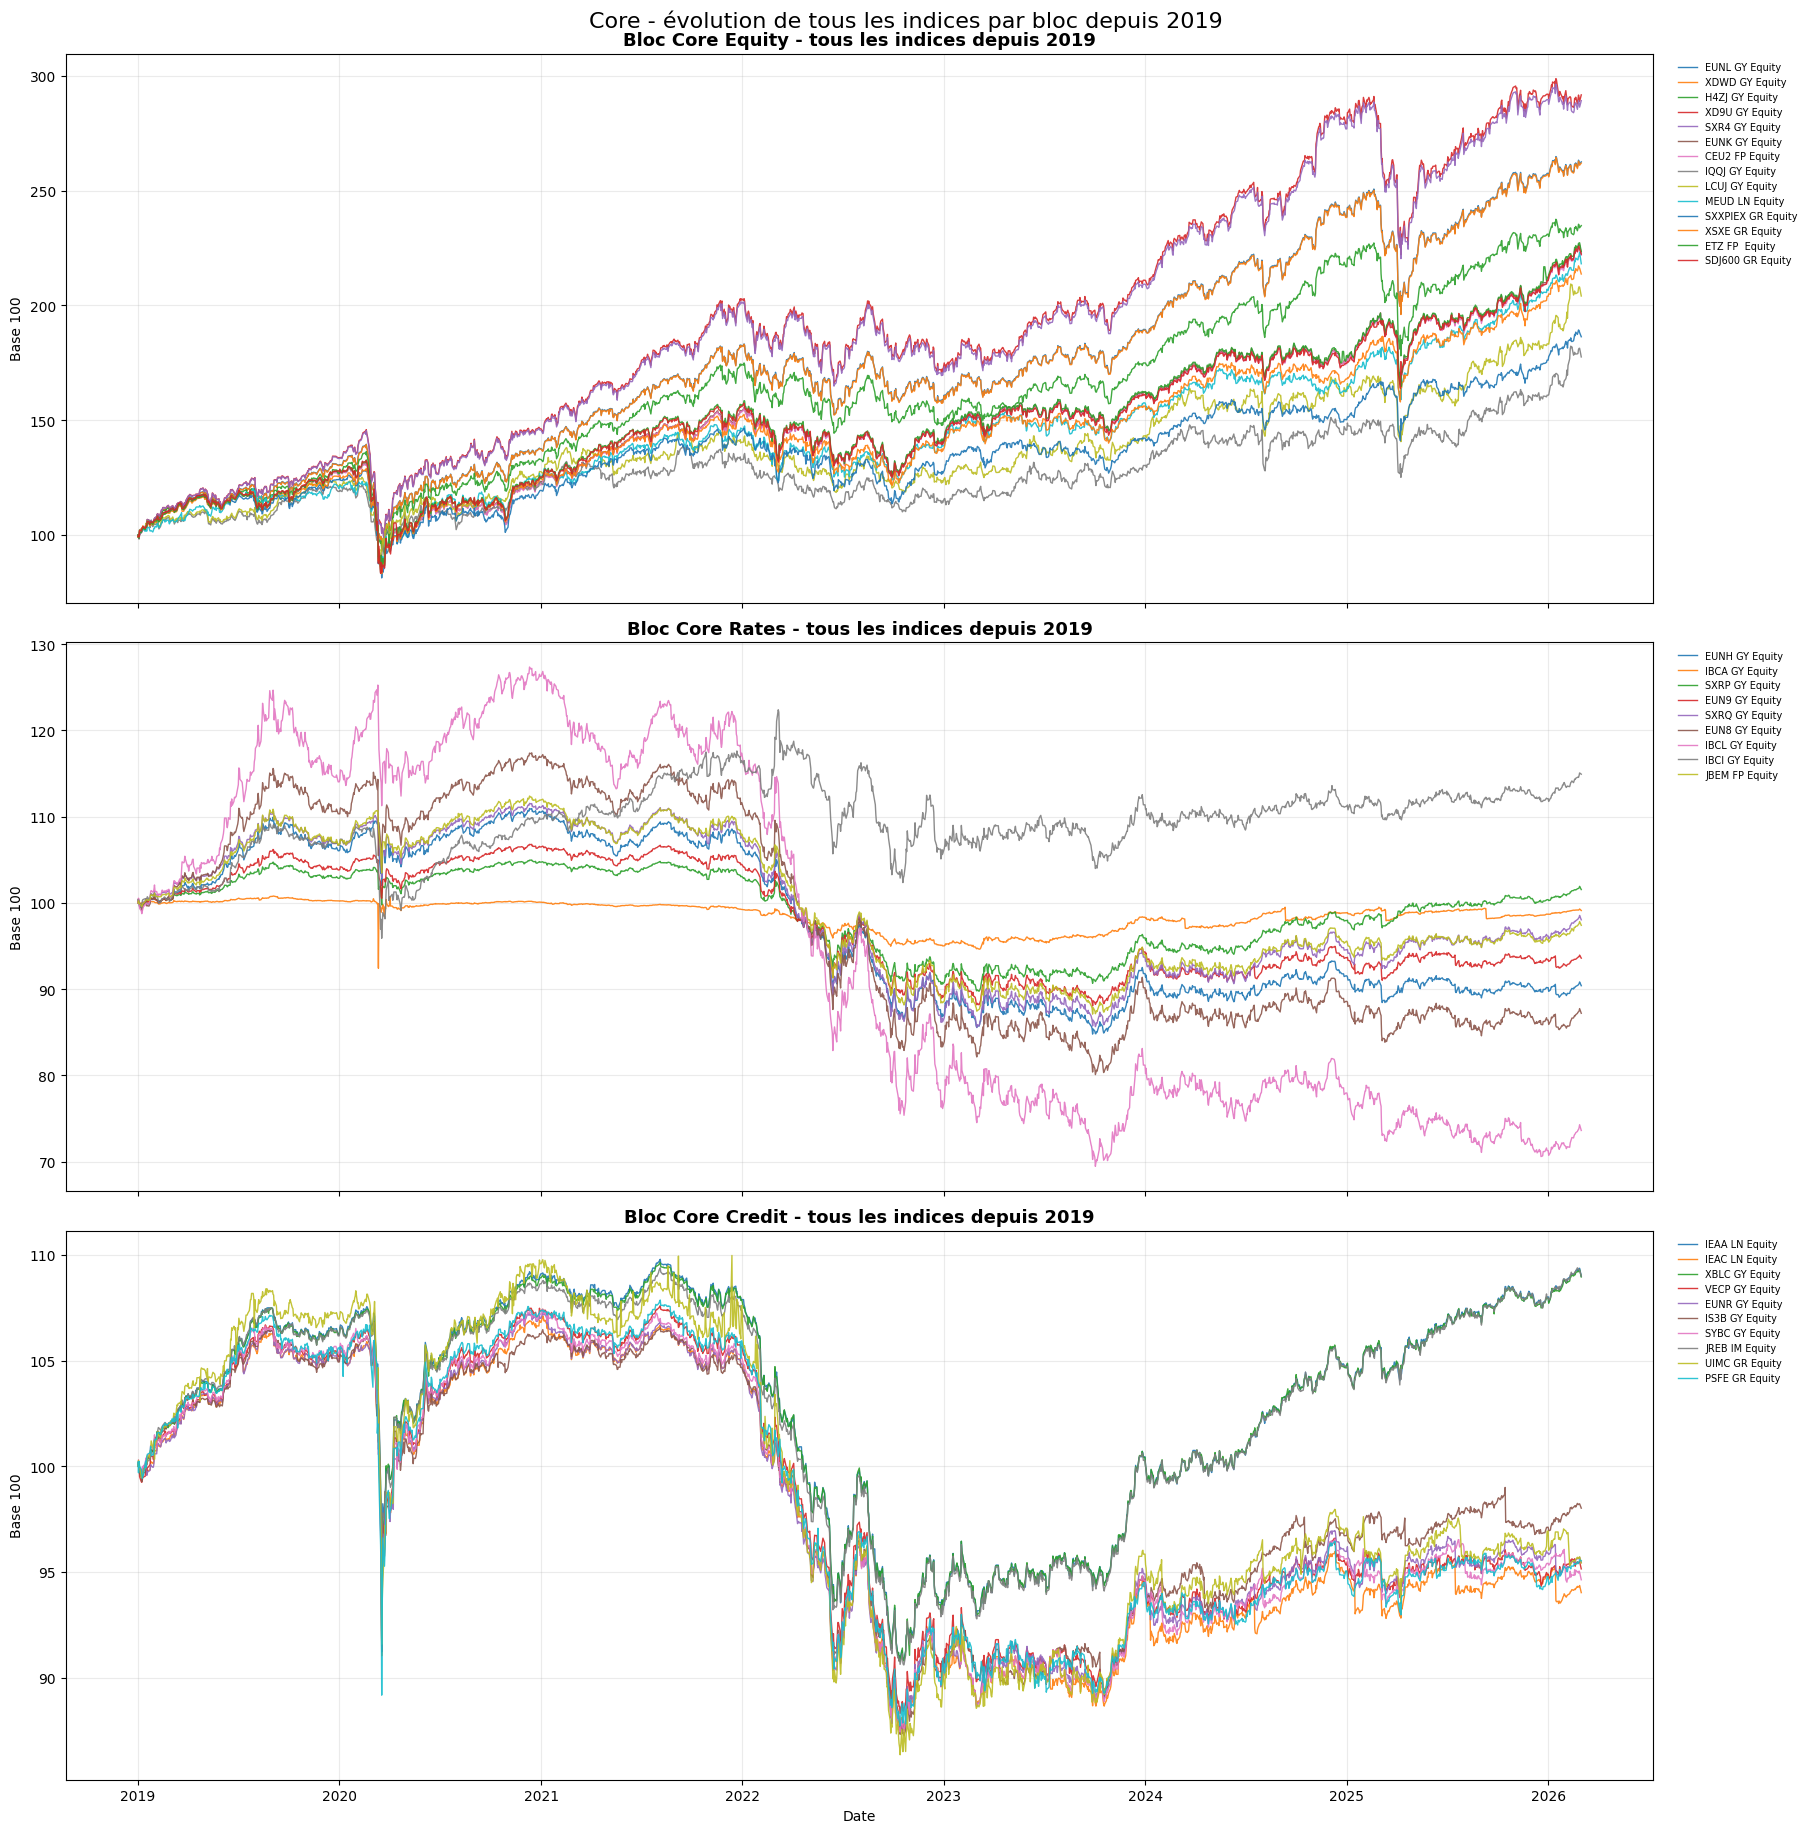

Figure sauvegardée : outputs/figures/core_blocs_tous_indices_depuis_2019.png


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(18, 18), sharex=True, constrained_layout=True)

for ax, (block_name, data) in zip(axes, block_data.items()):
    rebased = data['rebased']
    for ticker in rebased.columns:
        series = rebased[ticker].dropna()
        if len(series) == 0:
            continue
        ax.plot(series.index, series.values, linewidth=1.0, alpha=0.9, label=ticker)

    ax.set_title(f'Bloc Core {block_name} - tous les indices depuis 2019', fontsize=13, fontweight='bold')
    ax.set_ylabel('Base 100')
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), fontsize=7, frameon=False, ncol=1)

axes[-1].set_xlabel('Date')
fig.suptitle('Core - évolution de tous les indices par bloc depuis 2019', fontsize=16, y=1.01)

fig_path = OUTPUT_DIR / 'core_blocs_tous_indices_depuis_2019.png'
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Figure sauvegardée : {fig_path}')

In [18]:
for block_name, data in block_data.items():
    print('=' * 110)
    print(f'Tableau volatilité annualisée - bloc {block_name} (depuis 2019)')
    print('=' * 110)
    display(
        data['vol_table'].style.format({
            'ter_pct': '{:.2f}',
            'vol_annualisee': '{:.2%}',
        })
    )

Tableau volatilité annualisée - bloc Equity (depuis 2019)


,ticker,nom,exposition,ter_pct,devise,provider,first_valid_date,n_obs_returns,vol_annualisee
0,SDJ600 GR Equity,nan,nan,nan,nan,nan,2015-01-01,1869,17.74%
1,XD9U GY Equity,Xtrackers MSCI USA UCITS ETF 1C,MSCI USA,0.03,EUR,Xtrackers,2015-01-01,1869,17.08%
2,SXR4 GY Equity,iShares MSCI USA UCITS ETF (Acc),MSCI USA,0.03,EUR,iShares,2015-01-01,1869,17.07%
3,LCUJ GY Equity,Amundi Core MSCI Japan UCITS ETF Acc,MSCI Japan,0.12,EUR,Amundi,2018-03-21,1869,16.84%
4,IQQJ GY Equity,nan,nan,nan,nan,nan,2015-01-01,1869,16.80%
5,SXXPIEX GR Equity,nan,nan,nan,nan,nan,2015-01-01,1869,16.74%
6,ETZ FP Equity,nan,nan,nan,nan,nan,2015-01-01,1869,16.59%
7,XSXE GR Equity,nan,nan,nan,nan,nan,2018-06-26,1869,16.41%
8,CEU2 FP Equity,nan,nan,nan,nan,nan,2016-11-17,1869,16.13%
9,XDWD GY Equity,Xtrackers MSCI World UCITS ETF 1C,"MSCI World (développés, large/mid cap)",0.12,EUR,Xtrackers,2015-01-01,1869,16.01%


Tableau volatilité annualisée - bloc Rates (depuis 2019)


,ticker,nom,exposition,ter_pct,devise,provider,first_valid_date,n_obs_returns,vol_annualisee
0,IBCL GY Equity,iShares Euro Government Bond 15-30yr UCITS ETF (Dist),Govies EMU IG – 15-30 ans,0.15,EUR,iShares,2015-01-01,1869,12.38%
1,EUN8 GY Equity,iShares Euro Government Bond 10-15yr UCITS ETF,Govies EMU IG – 10-15 ans,0.15,EUR,iShares,2015-01-01,1869,9.00%
2,IBCI GY Equity,iShares Euro Inflation Linked Government Bond UCITS ETF,Govies EMU IG indexés inflation,0.09,EUR,iShares,2015-01-01,1869,6.74%
3,SXRQ GY Equity,iShares Euro Government Bond 7-10yr UCITS ETF (Acc),Govies EMU IG – 7-10 ans,0.15,EUR,iShares,2015-01-01,1869,6.45%
4,EUNH GY Equity,iShares Core Euro Government Bond UCITS ETF (Dist),Govies EMU IG – broad all maturities,0.07,EUR,iShares,2015-01-01,1869,6.03%
5,JBEM FP Equity,nan,nan,nan,nan,nan,2017-06-01,1869,5.57%
6,EUN9 GY Equity,iShares Euro Government Bond 5-7yr UCITS ETF,Govies EMU IG – 5-7 ans,0.15,EUR,iShares,2015-01-01,1869,4.77%
7,IBCA GY Equity,iShares Euro Government Bond 1-3yr UCITS ETF (Dist),Govies EMU IG – 1-3 ans,0.15,EUR,iShares,2015-01-01,1869,4.48%
8,SXRP GY Equity,iShares Euro Government Bond 3-7yr UCITS ETF (Acc),Govies EMU IG – 3-7 ans,0.15,EUR,iShares,2015-01-01,1869,3.83%


Tableau volatilité annualisée - bloc Credit (depuis 2019)


,ticker,nom,exposition,ter_pct,devise,provider,first_valid_date,n_obs_returns,vol_annualisee
0,UIMC GR Equity,nan,nan,nan,nan,nan,2017-01-24,1869,7.42%
1,PSFE GR Equity,nan,nan,nan,nan,nan,2017-11-20,1869,5.91%
2,VECP GY Equity,Vanguard EUR Corporate Bond UCITS ETF (EUR) Distributing,Corporate IG EUR – toutes maturités,0.07,EUR,Vanguard,2017-10-26,1869,5.39%
3,SYBC GY Equity,State Street SPDR Bloomberg Euro Corporate Bond UCITS ETF EUR,Corporate IG EUR – toutes maturités,0.12,EUR,SPDR,2015-01-01,1869,5.23%
4,XBLC GY Equity,Xtrackers II EUR Corporate Bond UCITS ETF 1C,Corporate IG EUR – toutes maturités,0.09,EUR,Xtrackers,2015-01-01,1869,5.16%
5,IEAC LN Equity,iShares Core EUR Corporate Bond UCITS ETF (Dist),Corporate IG EUR – toutes maturités,0.09,EUR,iShares,2015-01-01,1869,5.15%
6,EUNR GY Equity,iShares EUR Corporate Bond ex-Financials UCITS ETF EUR (Dist),Corporate IG EUR ex-Financials – toutes maturités,0.20,EUR,iShares,2015-01-01,1869,5.15%
7,IS3B GY Equity,iShares EUR Corporate Bond Financials UCITS ETF,Corporate IG EUR Financials – toutes maturités,0.20,EUR,iShares,2015-01-01,1869,5.01%
8,IEAA LN Equity,nan,nan,nan,nan,nan,2017-09-25,1869,4.92%
9,JREB IM Equity,nan,nan,nan,nan,nan,2018-12-13,1869,4.91%
